In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
X_train = pd.read_csv("../data/X_rf_train.csv")
X_test = pd.read_csv("../data/X_rf_test.csv")
y_train = pd.read_csv("../data/y_train.csv")
y_test = pd.read_csv("../data/y_test.csv")

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [18]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [19]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [20]:
lr.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred=lr.predict(X_test_scaled)

In [22]:
from sklearn.metrics import(r2_score,mean_absolute_error,mean_squared_error)
r2=r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

In [23]:
print("r2: ",r2)
print("mae: ",mae)
print("rmse: ",rmse)


r2:  0.5562674546508295
mae:  0.2141866918293976
rmse:  0.3822838136944937


In [24]:
y_train_pred = lr.predict(X_train_scaled)
train_r2 = r2_score(y_train,y_train_pred)
print("Train R2:", round(train_r2,4))

Train R2: 0.5045


In [25]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(lr,X_train_scaled,y_train,cv=10,scoring="r2",n_jobs=-1)
print("Fold Scores:")
print(cv_scores)
print()
print("Mean CV R2:",round(cv_scores.mean(),4))
print("Std CV R2:",round(cv_scores.std(),4))

Fold Scores:
[0.45303002 0.44048962 0.62226415 0.56612722 0.49648478 0.51090779
 0.28815952 0.52730292 0.35225635 0.47800941]

Mean CV R2: 0.4735
Std CV R2: 0.0928


In [26]:
df=pd.read_csv("../data/DataWithDescriptors.csv")
df.columns

Index(['Unnamed: 0', 'IL NAME', 'CATION NAME', 'ANION NAME', 'Cation_SMILES',
       'Anion_SMILES', 'Temperature (0 C)', 'Pressure (bar)',
       'CO2 capacity (mol CO2/mol IL)', 'Cation_Family',
       ...
       'An_fr_sulfide', 'An_fr_sulfonamd', 'An_fr_sulfone',
       'An_fr_term_acetylene', 'An_fr_tetrazole', 'An_fr_thiazole',
       'An_fr_thiocyan', 'An_fr_thiophene', 'An_fr_unbrch_alkane',
       'An_fr_urea'],
      dtype='str', length=444)

In [27]:
features=pd.read_excel("../data/RF_Top20_Features.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: '../data/RF_Top20_Features.xlsx'

In [ ]:
rf_features = features.iloc[:,0].tolist()

print(rf_features)
print(len(rf_features))

['Pressure (bar)', 'Temperature (0 C)', 'Cat_MolLogP', 'Cat_EState_VSA2', 'An_TPSA', 'Cat_VSA_EState3', 'An_AvgIpc', 'An_SlogP_VSA1', 'Cat_TPSA', 'Cat_EState_VSA9', 'Cat_BCUT2D_LOGPLOW', 'Cat_NumHDonors', 'Cat_SMR_VSA5', 'Cat_SMR_VSA1', 'Cat_PEOE_VSA1', 'Cat_NHOHCount', 'Cat_EState_VSA8', 'Cat_Chi4v', 'An_BalabanJ', 'An_PEOE_VSA3']
20


In [ ]:
ranged_df=df[(df["Temperature (0 C)"] >= 25) &(df["Temperature (0 C)"] <= 30) &(df["Pressure (bar)"] >= 0.5) &(df["Pressure (bar)"] <= 1.5)].copy()

In [ ]:
X_ranged = ranged_df[rf_features]

X_ranged_scaled = scaler.transform(X_ranged)

In [ ]:
ranged_df["LR_Pred"] = lr.predict(
    X_ranged_scaled
)

In [ ]:
rf_ranking = (ranged_df.groupby("IL NAME")["LR_Pred"].mean().reset_index())

In [ ]:
top5_rf = rf_ranking.sort_values(by="LR_Pred",ascending=False).head(10)

print(top5_rf)

          IL NAME   LR_Pred
1     [AmemI][Br]  1.749208
68    [TETAH][Pz]  1.497183
67    [TETAH][Py]  1.359684
66    [TETAH][Im]  1.355647
69    [TETAH][Tz]  1.332980
71  [aP4443][Ala]  1.297470
23    [DETA][Oct]  1.118454
20  [DETA][ Hex]   1.116894
21    [DETA][But]  1.116117
22    [DETA][For]  1.083722


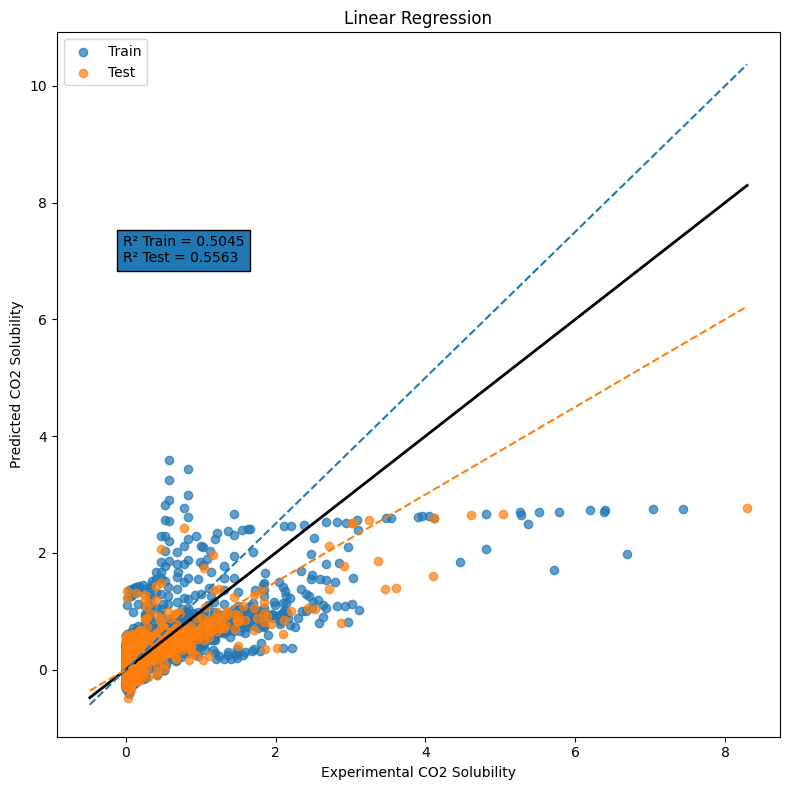

In [29]:
all_values = np.concatenate([
    y_train,
    y_test,
    y_train_pred,
    y_pred
])

xmin = all_values.min()
xmax = all_values.max()

# Perfect prediction line
x_line = np.linspace(xmin, xmax, 100)

# ±25%
upper = x_line * 1.25
lower = x_line * 0.75

plt.figure(figsize=(8,8))

# Train
plt.scatter(
    y_train,
    y_train_pred,
    label="Train",
    alpha=0.7
)

# Test
plt.scatter(
    y_test,
    y_pred,
    label="Test",
    alpha=0.7
)

# Perfect prediction
plt.plot(
    x_line,
    x_line,
    color="black",
    linewidth=2
)

# +25%
plt.plot(
    x_line,
    upper,
    linestyle="--"
)

# -25%
plt.plot(
    x_line,
    lower,
    linestyle="--"
)

plt.xlabel("Experimental CO2 Solubility")
plt.ylabel("Predicted CO2 Solubility")

plt.legend()

plt.text(
    xmin + 0.05*(xmax-xmin),
    xmax - 0.15*(xmax-xmin),
    f"R² Train = {train_r2:.4f}\nR² Test = {r2:.4f}",
    bbox=dict()
)

plt.title("Linear Regression")

plt.tight_layout()

plt.show()

In [32]:
residuals = y_test - y_pred

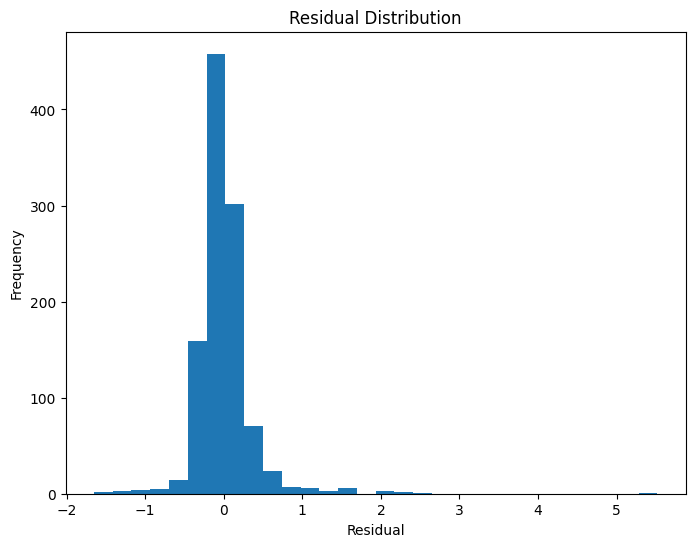

In [33]:
plt.figure(figsize=(8,6))

plt.hist(
    residuals,
    bins=30
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.show()